In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [8]:
sentiment_df = pd.read_parquet("outputs/sentiment_instagram.parquet")
sentiment_df["sentiment_score"] = pd.to_numeric(sentiment_df["sentiment_score"], errors="coerce")
sentiment_df["sentiment"] = sentiment_df["sentiment"].fillna("neutral")
print(f"Loaded {len(sentiment_df):,} comments")

Loaded 497,861 comments


## Analysis & QA

The headline distributions including the positive / negative / neutral split that motivated this notebook.

In [9]:
df = sentiment_df.copy()
n = len(df)
print(f"Analysed comments: {n:,}\n")

print("=== Sentiment distribution ===")
vc = df["sentiment_cat"].value_counts()
for k, v in vc.items():
    print(f"  {str(k):10} {v:7,}  ({v/n:6.1%})")
print(f"\n  mean sentiment score: {df['sentiment_score'].mean():+.3f}")

print("\n=== Top emotions ===")
for k, v in df["emotion"].value_counts().head(12).items():
    print(f"  {str(k):14} {v:7,}  ({v/n:5.1%})")

print(f"\n=== Sarcasm / irony ===  {df['sarcasm'].fillna(False).mean():.1%} flagged sarcastic")

print("\n=== Toxicity ===")
for k, v in df["toxicity"].value_counts().items():
    print(f"  {str(k):8} {v:7,}  ({v/n:5.1%})")

print("\n=== Intent ===")
for k, v in df["intent"].value_counts().head(10).items():
    print(f"  {str(k):12} {v:7,}  ({v/n:5.1%})")

if "media_context" in df.columns and df["media_context"].nunique() > 1:
    print("\n=== With vs. without media context (mean score) ===")
    print(df.groupby("media_context")["sentiment_score"].agg(["count", "mean"]).round(3))

Analysed comments: 497,861

=== Sentiment distribution ===
  positive   401,396  ( 80.6%)
  neutral     68,596  ( 13.8%)
  negative    27,869  (  5.6%)

  mean sentiment score: +0.579

=== Top emotions ===
  joy            231,959  (46.6%)
  amusement       56,160  (11.3%)
  affection       52,478  (10.5%)
  anticipation    31,590  ( 6.3%)
  sadness         15,581  ( 3.1%)
  surprise        15,371  ( 3.1%)
  admiration      15,303  ( 3.1%)
  neutral         14,872  ( 3.0%)
  none            12,810  ( 2.6%)
  trust           12,506  ( 2.5%)
  other           10,674  ( 2.1%)
  disgust          7,738  ( 1.6%)

=== Sarcasm / irony ===  3.4% flagged sarcastic

=== Toxicity ===
  none     494,630  (99.4%)
  mild       2,704  ( 0.5%)
  severe       523  ( 0.1%)
  spam_promo       4  ( 0.0%)

=== Intent ===
  praise       181,690  (36.5%)
  joke          84,194  (16.9%)
  affection     59,329  (11.9%)
  support       42,831  ( 8.6%)
  other         39,319  ( 7.9%)
  tag_share     33,284  ( 6.7

## Room Vibe: Post-Level Aggregation

Derives the **vibe of the room** under each post from comment-level sentiment:
- `vibe_score`: Overall polarity (mean sentiment)
- `consensus`: Agreement level [0,1]
- `controversy`: Presence of opposing camps [0,1]
- `polarization`: Spread of sentiment distribution [0,1]
- `stance_alignment`: Support for creator [-1,+1]

In [10]:
df = sentiment_df.copy()
LOG2_3 = np.log2(3)

def _norm_entropy(pos, neg, neu):
    """Normalised Shannon entropy of the {pos,neg,neu} label mix -> 0 (united) .. 1 (max spread)."""
    p = np.array([pos, neg, neu]); p = p[p > 0]
    return float(-(p * np.log2(p)).sum()) / LOG2_3 if len(p) else 0.0

# Group by post (media_id)
rows = []
for mid, g in df.groupby("media_id"):
    n = len(g)
    s = g["sentiment_score"].dropna()
    lab = g["sentiment"]
    pos = float((lab == "positive").mean())
    neg = float((lab == "negative").mean())
    neu = float(max(0.0, 1 - pos - neg))
    rows.append({
        "media_id": mid,
        "n_comments": n,
        "vibe_score": float(s.mean()) if len(s) else np.nan,
        "vibe_std": float(s.std(ddof=0)) if len(s) > 1 else 0.0,
        "pos_frac": pos,
        "neg_frac": neg,
        "neu_frac": neu,
        "stance_alignment": float(np.sign(s).mean()) if len(s) else np.nan,
        "polarization": 2 * min(pos, neg),
        "controversy": 4 * pos * neg,
        "consensus": 1 - _norm_entropy(pos, neg, neu),
        "sarcasm_rate": float(g["sarcasm"].fillna(False).mean()),
        "toxicity_rate": float((g["toxicity"].fillna("none") != "none").mean()),
    })

room = pd.DataFrame(rows)

def _room_state(r):
    if r["controversy"] >= 0.3:
        return "divided"
    if r["consensus"] >= 0.6:
        return "united"
    return "mixed"

room["room_state"] = room.apply(_room_state, axis=1)

print(f"Room vibe for {len(room):,} posts")
print(room[["media_id", "vibe_score", "consensus", "controversy", "stance_alignment"]].head())

Room vibe for 1,501 posts
            media_id  vibe_score  consensus  controversy  stance_alignment
0  17842069565943166    0.636709   0.534498     0.128826          0.848101
1  17842096630720198    0.504301   0.355724     0.058273          0.795699
2  17842202125145869    0.664394   0.568016     0.051423          0.939394
3  17842339006942337    0.580242   0.505400     0.065687          0.891129
4  17842341109244847    0.497959   0.355519     0.054977          0.816327


In [11]:
# Export contract output for persona_pipeline
post_vibes = room[["media_id", "vibe_score", "consensus", "stance_alignment"]].copy()
post_vibes.rename(columns={
    "vibe_score": "room_vibe",
    "consensus": "room_consensus"
}, inplace=True)

output_path = "outputs/post_vibes_instagram.parquet"
post_vibes.to_parquet(output_path, index=False)
print(f"Saved {len(post_vibes):,} post vibes to {output_path}")

Saved 1,501 post vibes to outputs/post_vibes_instagram.parquet


## Visualizations

Informative plots over sentiment distributions and room-level metrics.

In [12]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.axisbelow": True, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
FIG_DIR = "outputs/figs"
os.makedirs(FIG_DIR, exist_ok=True)
POS_C, NEU_C, NEG_C = "#2e9e5b", "#b0b0b0", "#d1495b"
NEUTRAL_BAND = 0.15

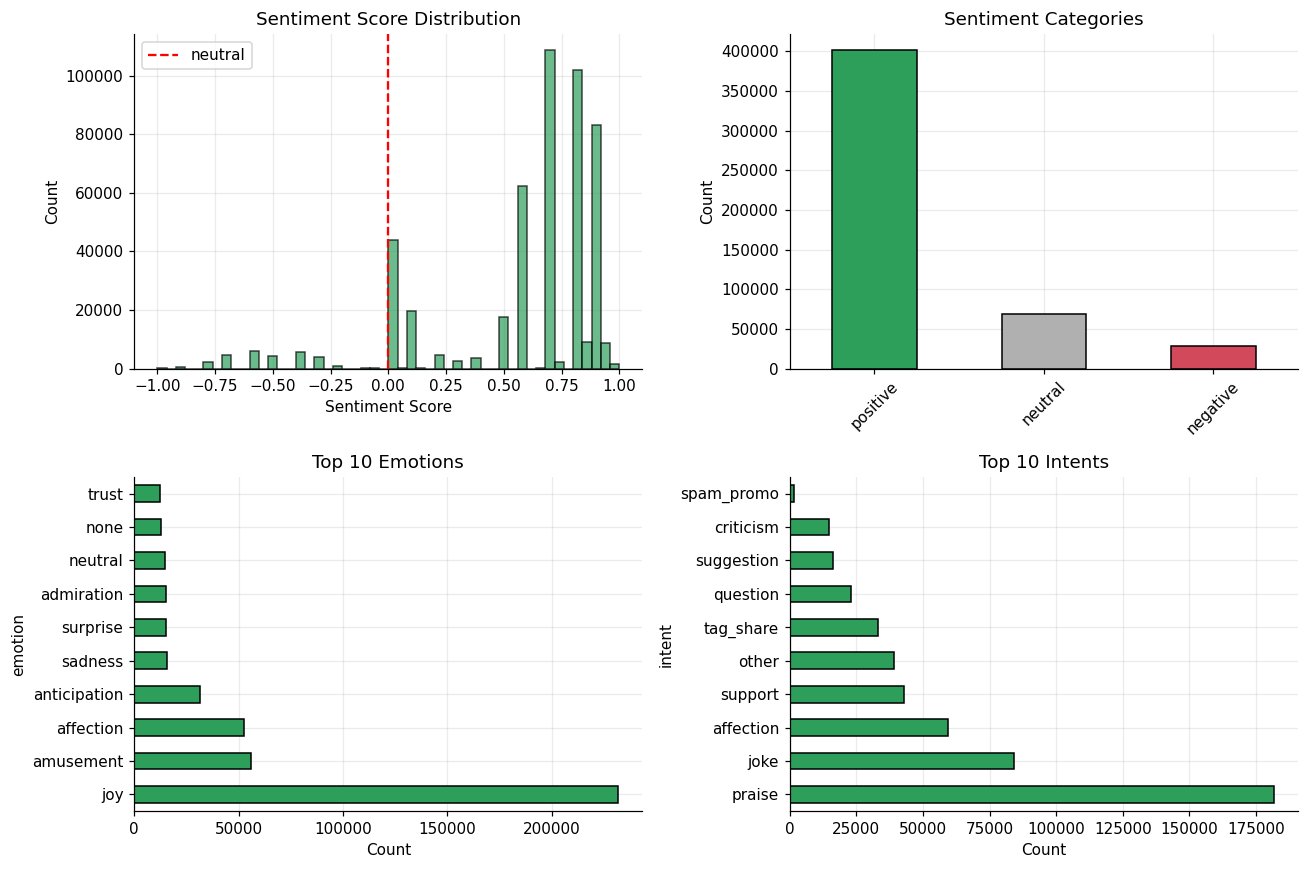

Saved sentiment_overview.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Sentiment score distribution
ax = axes[0, 0]
df["sentiment_score"].hist(bins=50, ax=ax, color=POS_C, edgecolor="k", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", label="neutral")
ax.set_xlabel("Sentiment Score"); ax.set_ylabel("Count")
ax.set_title("Sentiment Score Distribution")
ax.legend()

# Sentiment categories
ax = axes[0, 1]
vc = df["sentiment_cat"].value_counts()
colors = [POS_C if x == "positive" else NEG_C if x == "negative" else NEU_C for x in vc.index]
vc.plot(kind="bar", ax=ax, color=colors, edgecolor="k")
ax.set_title("Sentiment Categories"); ax.set_xlabel(""); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

# Emotions
ax = axes[1, 0]
df["emotion"].value_counts().head(10).plot(kind="barh", ax=ax, color=POS_C, edgecolor="k")
ax.set_title("Top 10 Emotions"); ax.set_xlabel("Count")

# Intent
ax = axes[1, 1]
df["intent"].value_counts().head(10).plot(kind="barh", ax=ax, color=POS_C, edgecolor="k")
ax.set_title("Top 10 Intents"); ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/sentiment_overview.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved sentiment_overview.png")

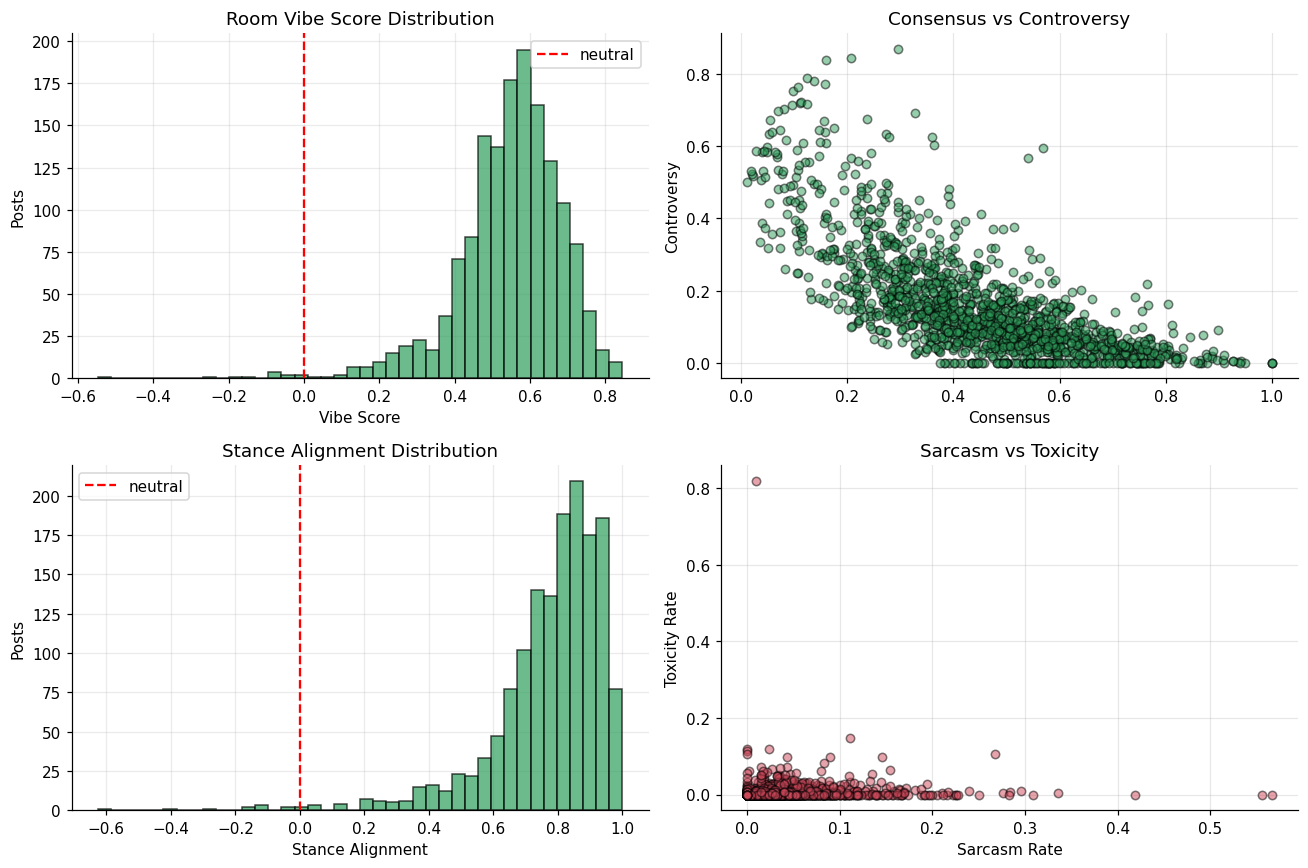

Saved room_vibe_overview.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Vibe score distribution
ax = axes[0, 0]
room["vibe_score"].hist(bins=40, ax=ax, color=POS_C, edgecolor="k", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", label="neutral")
ax.set_xlabel("Vibe Score"); ax.set_ylabel("Posts")
ax.set_title("Room Vibe Score Distribution")
ax.legend()

# Consensus vs Controversy
ax = axes[0, 1]
ax.scatter(room["consensus"], room["controversy"], alpha=0.5, s=30, color=POS_C, edgecolor="k")
ax.set_xlabel("Consensus"); ax.set_ylabel("Controversy")
ax.set_title("Consensus vs Controversy")
ax.grid(True, alpha=0.3)

# Stance alignment
ax = axes[1, 0]
room["stance_alignment"].hist(bins=40, ax=ax, color=POS_C, edgecolor="k", alpha=0.7)
ax.axvline(0, color="red", linestyle="--", label="neutral")
ax.set_xlabel("Stance Alignment"); ax.set_ylabel("Posts")
ax.set_title("Stance Alignment Distribution")
ax.legend()

# Sarcasm & Toxicity rates
ax = axes[1, 1]
ax.scatter(room["sarcasm_rate"], room["toxicity_rate"], alpha=0.5, s=30, color=NEG_C, edgecolor="k")
ax.set_xlabel("Sarcasm Rate"); ax.set_ylabel("Toxicity Rate")
ax.set_title("Sarcasm vs Toxicity")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/room_vibe_overview.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved room_vibe_overview.png")

In [ ]:
rv = room[room["n_comments"] >= 3].copy()
STATE_C = {"united": POS_C, "mixed": NEU_C, "divided": NEG_C}
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) the vibe map: polarity vs controversy, size = #comments, colour = room_state
for st, gdf in rv.groupby("room_state"):
    ax[0].scatter(gdf["vibe_score"], gdf["controversy"],
                  s=gdf["n_comments"].clip(upper=200) * 1.4 + 12,
                  c=STATE_C.get(st, "#777"), alpha=0.55, edgecolor="white", linewidth=0.5, label=st)
ax[0].axvline(0, color="k", lw=0.6)
ax[0].set_xlabel("Vibe Score (polarity)")
ax[0].set_ylabel("Controversy")
ax[0].set_title("Room Vibe Map (size = #comments)")
ax[0].legend(title="room_state")
ax[0].grid(True, alpha=0.3)

# (b) room_state proportions
rs = rv["room_state"].value_counts(normalize=True).reindex(["united", "mixed", "divided"]).fillna(0)
ax[1].bar(rs.index, rs.values, color=[STATE_C[s] for s in rs.index], edgecolor="k")
for i, v in enumerate(rs.values):
    ax[1].text(i, v, f"{v:.0%}", ha="center", va="bottom")
ax[1].set_ylim(0, 1)
ax[1].set_title("Room State Proportions")
ax[1].set_ylabel("Proportion")

# (c) consensus distribution
ax[2].hist(rv["consensus"], bins=30, color=POS_C, edgecolor="k", alpha=0.7)
ax[2].axvline(rv["consensus"].mean(), color="red", linestyle="--", linewidth=2, label=f"mean: {rv['consensus'].mean():.2f}")
ax[2].set_xlabel("Consensus")
ax[2].set_ylabel("Posts")
ax[2].set_title("Consensus Distribution")
ax[2].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_room_vibe_map.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved 02_room_vibe_map.png")

## Room-Level Vibe Map

Post vibe polarity vs controversy, room state proportions, and vibe distribution.

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))

# (a) mean score by emotion
em = sent.groupby("emotion")["sentiment_score"].mean().sort_values()
ecols = [POS_C if v > band else NEG_C if v < -band else NEU_C for v in em.values]
ax[0].barh(em.index, em.values, color=ecols)
ax[0].axvline(0, color="k", lw=0.6)
ax[0].set_title("Mean score by emotion")
ax[0].set_xlabel("mean sentiment_score")

# (b) correlation of engagement features with sentiment score
featcols = [c for c in ["word_count", "text_length", "avg_word_length", "emoji_count", "unique_emoji_count",
                         "exclamation_count", "question_count", "mention_count", "hashtag_count", "url_count"]
            if c in sent.columns]
if featcols:
    cor = (sent[featcols + ["sentiment_score"]].apply(pd.to_numeric, errors="coerce")
           .corr()["sentiment_score"].drop("sentiment_score").sort_values())
    ax[1].barh(cor.index, cor.values, color=["#c44e52" if v < 0 else "#55a868" for v in cor.values])
    ax[1].axvline(0, color="k", lw=0.6)
    ax[1].set_xlabel("Pearson r")
    ax[1].set_title("Feature-score correlation")
else:
    ax[1].axis("off")
    ax[1].set_title("No numeric features")

# (c) score by toxicity
torder = [t for t in ["none", "mild", "severe"] if (sent["toxicity"] == t).any()]
data = [sent.loc[sent["toxicity"] == t, "sentiment_score"].dropna().values for t in torder]
bp = ax[2].boxplot(data, showfliers=False, patch_artist=True)
for p, t in zip(bp["boxes"], torder):
    p.set_facecolor({"none": "#9e9e9e", "mild": "#e0a458", "severe": "#c44e52"}[t])
ax[2].set_xticks(range(1, len(torder) + 1))
ax[2].set_xticklabels(torder)
ax[2].axhline(0, color="k", lw=0.6)
ax[2].set_ylabel("sentiment_score")
ax[2].set_title("Score by toxicity")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_emotion_features.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved 04_emotion_features.png")

## Emotion & Feature Analysis

Mean score by emotion, feature-score correlations, and score by toxicity level.

In [ ]:
sent = df.copy()
band = NEUTRAL_BAND
order = ["negative", "neutral", "positive"]
CAT_COLORS = {"positive": POS_C, "neutral": NEU_C, "negative": NEG_C}

def _s2c(x):
    if pd.isna(x):
        return "neutral"
    return "positive" if x > band else "negative" if x < -band else "neutral"

num_cat = sent["sentiment_score"].map(_s2c)
agree = float((sent["sentiment_cat"] == num_cat).mean())
cat_prop = sent["sentiment_cat"].value_counts(normalize=True).reindex(order).fillna(0)
num_prop = num_cat.value_counts(normalize=True).reindex(order).fillna(0)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))

# (a) score distribution per categorical label
data = [sent.loc[sent["sentiment_cat"] == c, "sentiment_score"].dropna().values for c in order]
bp = ax[0].boxplot(data, showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(CAT_COLORS[c])
ax[0].set_xticks(range(1, 4))
ax[0].set_xticklabels(order)
ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_ylabel("sentiment_score")
ax[0].set_title("Score by label (should separate)")

# (b) categorical proportions vs proportions derived from the score
x = np.arange(3)
w = 0.38
ax[1].bar(x - w/2, cat_prop.values, w, label="categorical (LLM label)", color="#4c72b0")
ax[1].bar(x + w/2, num_prop.values, w, label="from score (band)", color="#dd8452")
for i in range(3):
    ax[1].text(i - w/2, cat_prop.values[i], f"{cat_prop.values[i]:.0%}", ha="center", va="bottom", fontsize=8)
    ax[1].text(i + w/2, num_prop.values[i], f"{num_prop.values[i]:.0%}", ha="center", va="bottom", fontsize=8)
ax[1].set_xticks(x)
ax[1].set_xticklabels(order)
ax[1].set_ylim(0, 1)
ax[1].legend()
ax[1].set_title("Label vs score-derived proportions")

# (c) agreement matrix (row-normalised)
ct = pd.crosstab(sent["sentiment_cat"], num_cat, normalize="index").reindex(order, fill_value=0)[order]
im = ax[2].imshow(ct.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax[2].set_xticks(range(3))
ax[2].set_yticks(range(3))
ax[2].set_xticklabels(order)
ax[2].set_yticklabels(order)
ax[2].set_xlabel("score-derived")
ax[2].set_ylabel("categorical label")
for i in range(3):
    for j in range(3):
        ax[2].text(j, i, f"{ct.iloc[i, j]:.0%}", ha="center", va="center", color="white" if ct.iloc[i, j] > 0.5 else "black")
ax[2].set_title(f"Agreement matrix (overall {agree:.0%})")
plt.colorbar(im, ax=ax[2])

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_crossval.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved 01_crossval.png")

## Cross-Validation: Categorical vs Numeric Agreement

Do the categorical labels agree with the numeric score? Box plots, proportions, and an agreement matrix.